# MJO 0: Overview

Example diagrams from [Physical Science Lab](psl.noaa.gov/mjo)
 <p align="center">
    <img src="https://preview.weather.gov/images/arx/lanina/MJO2.jpg">
</p>

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/psl/mjo/images/mjo_global_impacts.jpg">
</p>"

## MJO 1: Obtain Daily Model Data/Output

Read in daily model output via `daily.netcdf.ncl`"

`MJO_suite.py` - Line 44 - "OBTAINING DAILY OUTPUT"
```
generate_ncl_plots(os.environ["POD_HOME"]+"/daily_netcdf.ncl")
```

`daily_netcdf.ncl` reads daily output files from CAM2 and processes the data (each daily file has 30 days of data) (for example: U200(time, lat, lon))

Configuration file: `input_NCEP_Reanalysis_1980_1990.jsonc` (Configuration for MDTF-diagnostics driver script)

Additional details: [see here](https://mdtf-diagnostics.readthedocs.io/en/latest/sphinx/dev_cheatsheet.html#notes)

In [14]:
# Variable-specific environment variables which are accessed with os.environ()
# CASENAME =  "NCEP_Reanalysis"
# startdate = ???? (string in YYYYMMDD or YYYYMMDDHHMMSS for starting period of analysis)
# enddate =   ???? (string in YYYYMMDD or YYYYMMDDHHMMSS for ending period of analysis)

## DATADIR =  "data/day" (created in MJO_suite if doesn't already exist, L40)
# WORK_DIR =  (working directory) 

# U200_FILE = ???? (data file for 200-hPa zonal wind at lower boundary level, eastward wind in the atmosphere in m/s, scalar-coordinates where atmosphere pressure level lev=200)
# U850_FILE = ???? (data file for 850-hPa zonal wind at higher boundary level, eastward wind in the amotphere in m/s, scalar-coordinates where atmosphere pressure level lev=850)
# V200_FILE = ???? (data file for 200-hPa meridional wind, northward wind in the atmosphere in m/s, scalar-coordaintes where lev=200)
# RLUT_FILE = ???? (data file for outgoing longwave radiation, aka: OLR)
# PR_FILE =   ????

# lev_coord =  ???? (name of the level dimension, e.g. air pressure hPa (postive down, z-axis)
# lat_coord =  ???? (name of the latitude dimension in the model's native format, e.g. latitude in degrees North, y-axis)
# lon_coord =  ???? (name of the longitude dimension in the model's native format, e.g. longitude in degrees East, x-axis)
# time_coord = ???? (name of the time dimension in the model's native format)
# pr_var =     ???? (name of precipitation rate, in m/s, with the dimensions = "time, "lat", "lon" -- retained for backwards compatibility -> absolute path to the file containing "pr" data, for example, "/dir/precip.nc")
# rlut_var =   ???? (TOA Outgoing longwave flux/radiation, in W/m^2, with the dimensions = "time", "lat", "lon")

# setting.jsonc
# v850 = northward wind in m/s, scalar-coordinates where atmospheric pressure level lev = 850

In [119]:
# # getenv == os.environ
import os

CASENAME = "QBOi.EXP1.AMIP.001"
startdate = '19790101'
enddate = '19811231'

#DATADIR = "/glade/u/home/bundy/diag/mdtf/inputdata/model/QBOi.EXP1.AMIP.001/"
WORK_DIR = os.getcwd()
DATADIR = "/data/QBOi.EXP1.AMIP.001/day/"

U200_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.U200.day.nc"
V200_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.V200.day.nc"
U850_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.U850.day.nc"
RLUT_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.FLUT.day.nc"
PR_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.PRECT.day.nc"

lev_coord = "lev"
lat_coord = "lat"
lon_coord = "lon"
time_coord = "time"
pr_var = "PRECT"
rlut_var = "FLUT"

u200_var = "U200"
v200_var = "V200"

wk_dir = WORK_DIR + "/model/"

# setup data directory, if does not already exist
#if not os.path.exists(DATADIR): os.makedirs(DATADIR)

In [120]:
# check date format
from datetime import datetime

def check_date_format(date_in="", is_start=True):
    # update and check date format

    # if date string is empty
    if date_in == "":
        print(f"ERROR: No date_type given to function check_date_format()")
        return

    # if input is just YYYY, add in MMDDHH suffix
    if len(date_in) == 4:
        # if input if just YYYY, add MMDDHH
        if is_start: # is start date
            date_suffix = str(101 * 100) # 10 10 0 # TODO: month as 1 or 01?
        if not is_start: # is end date
            date_suffix = str(1231 * 100) # 12 31 00

        date_out = date_in + date_suffix
        #print(f"Corrected {date_in} date date to {date_out}")

    # if input is YYYYMMDD, but missing hours
    if len(date_in) == 8:
        date_out = date_in + "00"
        #print(f"Corrected {date_in} date to {date_out}")

    # if input is correct length, check format
    if len(date_in) == 10:
        date_out = date_in

    date_format = "%Y%m%d%H" # YYYYMMDDHH
    try:
        matches = bool(datetime.strptime(date_out, date_format))
    except ValueError:
        matches = False
    #print(f"{date_in} matches {date_format} = {matches}")
    #print(f"Final Date = {date_out}")
    return date_out

startdate = check_date_format(startdate, is_start=True)
enddate = check_date_format(enddate, is_start=False)

In [121]:
# daily_netcdf.ncl
# netCDF variables

print("Starting: Daily NETCDF")
casename = CASENAME
datadir = DATADIR
level = lev_coord
wk_dir = WORK_DIR + "/model/"
if not os.path.exists(wk_dir): os.makedirs(wk_dir)

file_u200 = U200_FILE
file_v200 = V200_FILE
file_u850 = U850_FILE
file_rlut = RLUT_FILE
file_pr = PR_FILE

print(f"daily_netcdf.ncl reading {file_pr} for time coordinates")
print("Assuming without checking that all have time coordinates")

Starting: Daily NETCDF
daily_netcdf.ncl reading /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.PRECT.day.nc for time coordinates
Assuming without checking that all have time coordinates


In [122]:
import xarray as xr
file_netcdf = xr.open_dataset(file_pr)
file_netcdf

<xarray.Dataset> Size: 565MB
Dimensions:    (time: 2555, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    PRECT      (time, lat, lon) float32 565MB ...

In [123]:
print(file_netcdf.variables.keys())
#print("\n")
#print(file_netcdf.variables)

KeysView(Frozen({'date': <xarray.Variable (time: 2555)> Size: 10kB
[2555 values with dtype=int32]
Attributes:
    long_name:  current date (YYYYMMDD), 'time_bnds': <xarray.Variable (time: 2555, nbnd: 2)> Size: 41kB
[5110 values with dtype=object]
Attributes:
    long_name:  time interval endpoints, 'PRECT': <xarray.Variable (time: 2555, lat: 192, lon: 288)> Size: 565MB
[141281280 values with dtype=float32]
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              m/s
    long_name:          Total (convective and large-scale) precipitation rate...
    cell_methods:       time: mean                                           ..., 'time': <xarray.IndexVariable 'time' (time: 2555)> Size: 20kB
array([cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1975, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1975, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(1981, 12, 29, 0, 0, 0, 0, has_year_z

In [124]:
yr1 = int(startdate)
yr2 = int(enddate)
print(yr1)
print(yr2)
print("\n")

1979010100
1981123100




In [125]:
import xarray as xr
file_xr = xr.open_dataset(file_pr)
time = file_xr.variables[time_coord]
print(time.attrs)
# TODO: find units/calendar, not visible with xarray, but below uses netCDF4
time

{'long_name': 'time', 'bounds': 'time_bnds'}


<xarray.IndexVariable 'time' (time: 2555)> Size: 20kB
array([cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1975, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1975, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(1981, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1981, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      shape=(2555,), dtype=object)
Attributes:
    long_name:  time
    bounds:     time_bnds

In [126]:
from netCDF4 import Dataset
file_netcdf = Dataset(file_pr)
time = file_netcdf[time_coord]
print(time) # includes the units and calendar (not in xarray?)

<class 'netCDF4.Variable'>
float64 time(time)
    long_name: time
    units: days since 1975-01-01 00:00:00
    calendar: noleap
    bounds: time_bnds
unlimited dimensions: 
current shape = (2555,)
filling on, default _FillValue of 9.969209968386869e+36 used


In [127]:
print("before:")
print(time.units)
print(time.calendar)

if (time.units == "julian day"): # if time units in Julian days, convert
    time.units = "days since -4713-01-01 00:00:00"
    time.calendar = "julian"

print("after:")
print(time.units)
print(time.calendar)

before:
days since 1975-01-01 00:00:00
noleap
after:
days since 1975-01-01 00:00:00
noleap


In [128]:
import numpy as np
days_since_date = time[:] # extract all time days since date
print(days_since_date[:10])

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [129]:
# convert mixed Julian/Gregorian date to a UT-referenced date
# via NCL: cd_calendar --> cd_calendar(time, -3)
# Returns values in YYYYMMDDHH as an integer

from datetime import datetime, timedelta

# start date as datetime
start_datetime = datetime(1975, 1, 1, 0, 0, 0)

# collect all datetimes
time_all = []
for day_since_start in days_since_date:
    next_day = (start_datetime + timedelta(days=day_since_start))
    day_YYYYMMDDHH = next_day.strftime("%Y%m%d%H")
    time_all.append(int(day_YYYYMMDDHH))

print(f"Start date = {time_all[0]}, End date = {time_all[-1]}, number of dates = {len(time_all)}")

Start date = 1975010100, End date = 1981122900, number of dates = 2555


In [130]:
i1 = 0
i2 = len(time_all) - 1
print(f"Time range in file: {time_all[i1]} - {time_all[i2]}")

Time range in file: 1975010100 - 1981122900


In [131]:
# confirm date format
start_time = check_date_format(str(yr1), is_start=True)
end_time = check_date_format(str(yr2), is_start=False)

In [132]:
# 24 hours tolerance allows for different time resolutions

tol = 24

for i in range(len(time_all)-1):
    #print(f"examining times {i} {time_all[i]}")
    if abs(int(time_all[i]) - int(start_time)) < tol:
        i1 = i
        print(f"Found start_time {time_all[i]} {end_time}")
    if abs(int(time_all[i]) - int(end_time)) < tol:    
        i2 = i
        print(f"Found end_time {time_all[i]} {end_time}")

print(f"Time range indices: {i1} {time_all[i1]} - {i2} {time_all[i2]}")

Found start_time 1979010100 1981123100
Time range indices: 1461 1979010100 - 2554 1981122900


In [133]:
date = time_all[i1:i2]
print("Using date range: ")
print([min(date), max(date)])
ndays = len(date)
print(ndays)

Using date range: 
[1979010100, 1981122800]
1093


In [134]:
# check if data array is monotonic (strictly increasing)
# TODO: fix
def check_monotonic(array):
    is_increasing = (
        # Check for increasing order sequence
        all(element >= array[index - 1] for index, element in enumerate(array) if index > 0)
    )
    try:
        assert is_increasing
    except Exception:
        print("ERROR: daily_netcdf.ncl finds dates are not monotonic increasing")
    
print(f"Is monotonic = {check_monotonic(date)}")

Is monotonic = None


In [139]:
# First just use read_model_file for pr here, then put into var loop below
from netCDF4 import Dataset

def read_dim(f, var_name, opt=None, upper_bound=None, lower_bound=None):
    print("running read_dim")
    routine_name = "read_dim"
    verbose = False
    if opt is not None:
        if lower_bound is not None:
            print(f"found lower_bound {lower_bound}")
        if upper_bound is not None:
            print(f"found upper_bound {upper_bound}")
    
    if lower_bound is not None and upper_bound is not None:
        var = f[var_name[lower_bound:upper_bound]]
    else:
        var = f[var_name]

    return var    

def get_gw(f, latS, latN):
    '''if "gw" in f.variables:
        del(f["gw"])
    new_gw = f[gw(lat_coord|latS:latN])
    '''
    print("running get_gw")
    lat = read_dim(f, lat_coord, opt=False, upper_bound=latN, lower_bound=latS)
    nlat = len(lat)
    slat = np.empty(shape=(nlat+1,), dtype="float")
    gw = np.empty(shape=(nlat+1,), dtype="float")
    gw = {"name": "lat"}
    gw["lat"] = lat
    #print(slat)

    if lat[0] < lat[1]:
        slat[0] = -90.0
        slat[nlat] = 90.0
    else:
        slat[0] = 90.0
        slat[nlat] = -90.0

    for i in range(nlat-1):
        slat[i] = (lat[i-1] + lat[i])/2

    for i in range(nlat-1):
        gw[i] = abs(np.sin(slat[i+1] / (180*np.pi)) - np.sin(slat[i] / (180 * np.pi)))
    #del(slat)

    new_gw = gw[lat_coord][latS:latN]

def pinterp(var_name=None, plev=None, fin=None, fin_ps=None):
    print(f"pinterop() interpolating {var_name} to pressure level {plev} mbar")        

def read_model_file(var_name_in=None, file_in=None,
                   var_name_out=None, file_out=None,
                   delete_existing=False,
                   i1=None, i2=None, time_coord=None,
                   lat_coord=None, lon_coord=None,
                   date=None, interp_opts=None,
                   var_name_in_3d=None, plev=None, file_3d=None, file_ps=None):
    # utils.ncl - L186
    # interp_opts = optional args for interpolating in space
    # var_name_in_3d, plev, file_3d, file_ps = optional args for pressure interp
    print("running read_model_file")

    latS = -40
    latN = 40
    opt = True
    lower_bound = latS
    upper_bound = latN

    if os.path.exists(file_out) and not delete_existing: # do not write new file
        print(f"WARNING: using existing file {file_out}")
        print(f"To override, change delete_existing to True")
        if interp_opts is not None:
            f_out_for_interp = Dataset(file_out)
            var = f_out_for_interp[var_name_out]
            gw = get_gw(f_out_for_interp, latS, latN)
            interp_save_res(var_name_out, interp_opts, var["lat"], var["lon"], gw)
            del(f_out_for_interp)
    else:
        print("write new file")
        if os.path.exists(file_out):
            print(f"WARNING: over-writing existing file {file_out}")
            os.remove(file_out)
        if os.path.exists(file_in):
            print(f"opening {var_name_in} from {file_in}")
            f_in = xr.open_dataset(file_in)
            #f_in = Dataset(file_in)
            lat = read_dim(f_in, lat_coord, opt, upper_bound=upper_bound, lower_bound=lower_bound)
            opt = False
            lon = read_dim(f_in, lon_coord, opt, upper_bound=upper_bound, lower_bound=lower_bound)
            gw = get_gw(f_in, latS, latN)

            print("FILE INPUT:")
            #var = f_in[var_name_in].sel(time=slice(
            time_start = f_in[var_name_in][i1].time.values
            time_end = f_in[var_name_in][i2].time.values
            print(time_start, time_end)
            ds = f_in[var_name_in]
            var = ds.sel(time=slice(time_start, time_end), lat=slice(-40, 40)) # L245 (utils.ncl)
            print(var)
        else:
            # TODO: fill out pinterp() function
            if os.path.exists(file_in):
                print(f"WARNING: file does not exist for MJO diagnostics: {file_in}")
                print(f"Looking for file matching {var_name_in_3d} at plev {plev}")

                # needs checks for var_name_in_3d, plev and file_ps
                if file_ps is None:
                    print(f"ERROR: can't find required PS file: {file_ps}")
                    return

                f_3d = xr.open_dataset(file_3d)
                f_ps = xr.open_dataset(file_ps)
                var_1 = pinterp(var_namae_in_3d, plev, f_3d, f_ps) #TODO
                var = ds.sel(time=slice(time_start, time_end), lat=slice(-40, 40)) # L245 (utils.ncl)
            if interp_opts:
                print("INTERP_OPTS IS TRUE")
                # TODO

    # Writing new file
    print(f"Creating output file {file_out}")
    try:
        file_out.close()
    except:
        pass

    var.to_netcdf(file_out)

In [140]:
# precipitation rate (pr)
print(f"daily_netcdf.ncl reading {file_pr} for making precip file!\n")
delete_existing = False # True = overwrite, False = don't overwrite

if os.path.exists(file_pr):
    print("found pr input file")
    var_name = pr_var
    var_name_out = "pr"
    file_in = file_pr
    file_out = wk_dir + CASENAME + "." + var_name_out + ".day.nc"
    print(file_out)
    var_name_3d_model = "not provided"
    file_in_3d = "not provided"
    file_in_ps = "not provided"
    plev = 0

    interp_opts = True # store this field as base resolution no matter what
    interp_to_var_name = var_name_out
    read_model_file(var_name, file_in, var_name_out, file_out, 
                    delete_existing, i1, i2, 
                    time_coord, lat_coord, lon_coord, date, interp_opts,
                    var_name_3d_model, plev, file_in_3d, file_in_ps)
else:
    print("ERROR: daily pr input files does not exist for MJO diagnostics")

daily_netcdf.ncl reading /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.PRECT.day.nc for making precip file!

found pr input file
/home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.nc
running read_model_file
write new file
opening PRECT from /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.PRECT.day.nc
running read_dim
found lower_bound -40
found upper_bound 40
running read_dim
found lower_bound -40
found upper_bound 40
running get_gw
running read_dim
found lower_bound -40
found upper_bound 40
FILE INPUT:
1979-01-02 00:00:00 1981-12-31 00:00:00
<xarray.DataArray 'PRECT' (time: 1094, lat: 84, lon: 288)> Size: 106MB
[26466048 values with dtype=float32]
Coordinates:
  * time     (time) object 9kB 1979-01-02 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 672B -39.11 -38.17 -37.23 ... 37.23 38.17 39.11
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Attributes

In [141]:
plevs = [850, 200]
var_names = ["u", "v"]

for i in range(len(plevs)):
    plev = plevs[i]
    for j in range(len(var_names)):
        var_name_3d_model = var_names[j] + "_var" # as read from history files (3d field)
        var_name_plev_model = var_names[j] + str(plev) + "_var" # as read from history files (pressure slice)
        var_name_plev_package = var_names[j] + str(plev) # new file name and varname in file
        file_var_name = var_names[j].upper() + str(plev) + "_FILE"
        file_in = file_var_name
        file_out = WORK_DIR + DATADIR + CASENAME + "." + var_name_plev_model + ".day.nc"
        print(file_out)
        # all files supplied to POD are 3D slices -> PS not part of varlist request
        file_in_3d = WORK_DIR + DATADIR + CASENAME + "." + var_name_3d_model + ".day.nc"
        print(file_in_3d)
        file_in_ps = WORK_DIR + DATADIR + CASENAME + ".PS.day.nc"
        print(file_in_ps)
        
        read_model_file(var_name, file_in, var_name_out, file_out, 
                    delete_existing, i1, i2, 
                    time_coord, lat_coord, lon_coord, date, interp_opts,
                    var_name_3d_model, plev, file_in_3d, file_in_ps)

/home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.u850_var.day.nc
/home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.u_var.day.nc
/home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.PS.day.nc
running read_model_file
write new file
INTERP_OPTS IS TRUE
Creating output file /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.u850_var.day.nc


UnboundLocalError: cannot access local variable 'var' where it is not associated with a value

In [142]:
# outgoing longwave radiation (rlut)

if os.path.exists(file_rlut):
    print(file_rlut)
    var_name = rlut_var
    file_in = file_rlut
    file_out = WORK_DIR + DATADIR + CASENAME + "." + var_name_out + ".day.nc"
    print(file_out)
    var_name_3d_model = "not provided"
    file_in_3d = "not provided"
    file_in_ps = "not provided"
    plev = 0

    read_model_file(var_name, file_in, var_name_out, file_out, 
                    delete_existing, i1, i2, 
                    time_coord, lat_coord, lon_coord, date, interp_opts,
                    var_name_3d_model, plev, file_in_3d, file_in_ps)
else:
    print("daily rlut file does not exist for MJO diagnostics")

/home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.FLUT.day.nc
/home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.pr.day.nc
running read_model_file
write new file
opening FLUT from /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001/day/QBOi.EXP1.AMIP.001.FLUT.day.nc
running read_dim
found lower_bound -40
found upper_bound 40
running read_dim
found lower_bound -40
found upper_bound 40
running get_gw
running read_dim
found lower_bound -40
found upper_bound 40
FILE INPUT:
1979-01-02 00:00:00 1981-12-31 00:00:00
<xarray.DataArray 'FLUT' (time: 1094, lat: 84, lon: 288)> Size: 106MB
[26466048 values with dtype=float32]
Coordinates:
  * time     (time) object 9kB 1979-01-02 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 672B -39.11 -38.17 -37.23 ... 37.23 38.17 39.11
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Attributes:
    cell_methods:       time: mean
    long_name: 

# MJO 2: Compute the Daily Anomalies

Via `daily_anom.ncl`

In [143]:
routine_name = "daily_anom"
file_dir = WORK_DIR + "/model/"
yr1 = int(startdate)
yr2 = int(enddate)

# encode datetime with milliseconds
print("datetimes: ")
start_date = (yr1 * 10000)+201       # 19790101 -> 197901010201
end_date = ((yr2 + 1) * 10000) + 101 # 19811231 -> 198112320101

print(start_date)
print(end_date)

delete_existing = False # True = overwrite, False = don't overwrite
if delete_existing:
    print("WARNING: daily_anom.ncl deleting existing anom files")
    print(f"File direcotry ({file_dir}) contains: {os.listdir(file_dir)}")   

datetimes: 
19790101000201
19811231010101


In [146]:
from netCDF4 import Dataset

var_names = ["pr", "rlut", "u200", "u850", "v200", "v850"]

# convert mixed Julian/Gregorian date to a UT-referenced date
# via NCL: cd_calendar --> cd_calendar(time, -2)
# Returns values in YYYYMMDD as an integer
def cd_calendar(date):
    from datetime import datetime, timedelta

    # start date as datetime
    start_datetime = datetime(1975, 1, 1, 0, 0, 0)
    
    # collect all datetimes
    time_all = []
    for day_since_start in days_since_date:
        next_day = (start_datetime + timedelta(days=day_since_start))
        day_YYYYMMDD = next_day.strftime("%Y%m%d")
        time_all.append(int(day_YYYYMMDD))
    
    print(f"Start date = {time_all[0]}, End date = {time_all[-1]}")
    return time_all

for i in range(len(var_names)):
    var_name = var_names[i]
    print(f"{routine_name} starting variable {var_name}")
    file_in = file_dir + CASENAME + "." + var_name + ".day.nc"
    print(f"File in:  {file_in}")
    file_out = file_dir + CASENAME + "." + var_name + ".day.anom.nc"
    #print(f"File out: {file_out}")

    if os.path.exists(file_out) and not delete_existing:
        print(f"{file_out} already exists. To force recalculation, set daily_anom.ncl delete_existing = {delete_existing}")
    else:
        if os.path.exists(file_out) and delete_existing:
            print(f"{file_out} already exists. Overwriting since delete_existing = {delete_existing}")
            os.remove(file_out)

        if os.path.exists(file_in):
            print(f"reading {file_in}")
        
            input_file = Dataset(file_in)
            time = input_file[time_coord]
            date = cd_calendar(time)

daily_anom starting variable pr
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.nc
reading /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.nc
Start date = 19750101, End date = 19811229
daily_anom starting variable rlut
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.rlut.day.nc
daily_anom starting variable u200
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.u200.day.nc
daily_anom starting variable u850
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.u850.day.nc
daily_anom starting variable v200
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.v200.day.nc
daily_anom starting variable v850
File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.v850.day.nc


In [147]:
# "compute_daily_anom() - L61
# function in calc_utils.ncl - L371

import xarray as xr
from geocat.comp import climate_anomaly
from matplotlib import pyplot as plt
import datetime


def compute_daily_anom(data_as_nc, is_plot=False):
    # compute the daily anomaly
    # See; calcDayAnom in geocat-applications
    ds = xr.open_dataset(data_as_nc)
    # calculates climate anomalies by subtracting the long-term mean of each 'freq' period (e.g. 'day')
    calcDayAnomTLL = climate_anomaly(dset=ds.aice_d,
                                     freq="day",
                                    tim_dim=None) # anomalies from daily climatology

    # optional plotting
    #if is_plot:
    #    calcDayAnomTLL[0, ;, ;].assign_attrs(long_name="CAM2 Anomaly").plot()
    return calcDayAnomTLL

# MJO 3: Calculate EOFs

Via `mjo_EOF.ncl`

Calculating the empirical orthognal functions (EOFs)

- [eofunc_eofs](https://geocat-comp.readthedocs.io/en/v2023.02.0/user_api/generated/geocat.comp.stats.eofunc_eofs.html): computes the empirical orthogonal functions (EOFs, aka: Principal Component Analysis. Python alterative to NCL function `eofunc`, built on [`eofs`](https://ajdawson.github.io/eofs/) package
- [geocat-example: NCL_eof_1_1.py](https://geocat-examples.readthedocs.io/en/latest/gallery/Contours/NCL_eof_1_1.html)

In [148]:
# input data
vars = ["pr", "rlut", "u200", "u850", "v200", "v850"]
file_dir = WORK_DIR + "/model"
filename_pr = file_dir + CASENAME + "pr.day.anom.nc"
ffilename_rlut = file_dir + CASENAME + "rlut.day.anom.nc"
filename_u200 = file_dir + CASENAME + "u200.day.anom.nc"
filename_u850 = file_dir + CASENAME + "u850.day.anom.nc"
filename_v200 = file_dir + CASENAME + "v200.day.anom.nc"
filename_v850 = file_dir + CASENAME + "v850.day.anom.nc"

seasons = ["winter", "summer"]

In [149]:
# EOF variables
neof = 4
latS = -30
latN = 30

pltDir = file_dir + "/PS" # directory for plots
pltType = "ps"

In [150]:
# calculate Guassian weights


In [151]:
# lanczo_hp_filter
def lanczo_hp_filter():#data, nWgt, fca, si

SyntaxError: incomplete input (1240579901.py, line 2)

In [ ]:
# create bandpass filter
ihp = 2 # bpf->band pass filter, 2 = band-pass
nWgt = 201 # number of weights (must be an odd number, the more weights, the better the filter, but the greater loss of data)
sigma = 1 # lanczos sigma
fca = 1/100 # indicating the cut-off frequency of the ideal high/low-pass filter (0.0 < fca < 0.5)
fcb = 1/20 # scalar used when band-pass filter is desired. It is the second cut-off frequency  (fca < fcb < 0.5)
wgt = filwgts_lanczo(nWgts, ihp, fca, fcb, sigma)

## calculate one-dimensional filter weights (filwgts_lanczos) 

In [ ]:
import xarray as xr
from geocat.comp import eofunc_eofs, eofunc_pcs

In [152]:
#ds = xr.

# MJO 3.5: Phase Diagrams Base (WIP)

Phase diagram split into 8 equal parts for example:

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/mjoindex/romi_cpcolr_phase_diag.png">
</p>

In [158]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_basemap(is_darkmode=False, start_date="Start", end_date="End"):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_xlabel("Bottom - Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax.set_ylabel("Left - Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax2.set_ylabel("Right - Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Top - Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), 1, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -1],
                               [0, 0],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                               [np.sin(7 * np.pi / 4), -4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-1, -4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                               [np.sin(7 * np.pi / 4), -4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([1, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                               [np.sin(np.pi / 4), 4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [1, 4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                               [np.sin(np.pi / 4), 4],
                               c=color_dm,
                               linestyle="--")
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
    ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
    ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
    ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
    ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
    ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
    ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
    ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    
    # plot with title
    plt.title(f"MJO Phase: 15S-15N: {start_date}-{end_date}", fontsize=30, fontweight="bold", pad=20)
    
    plt.show()

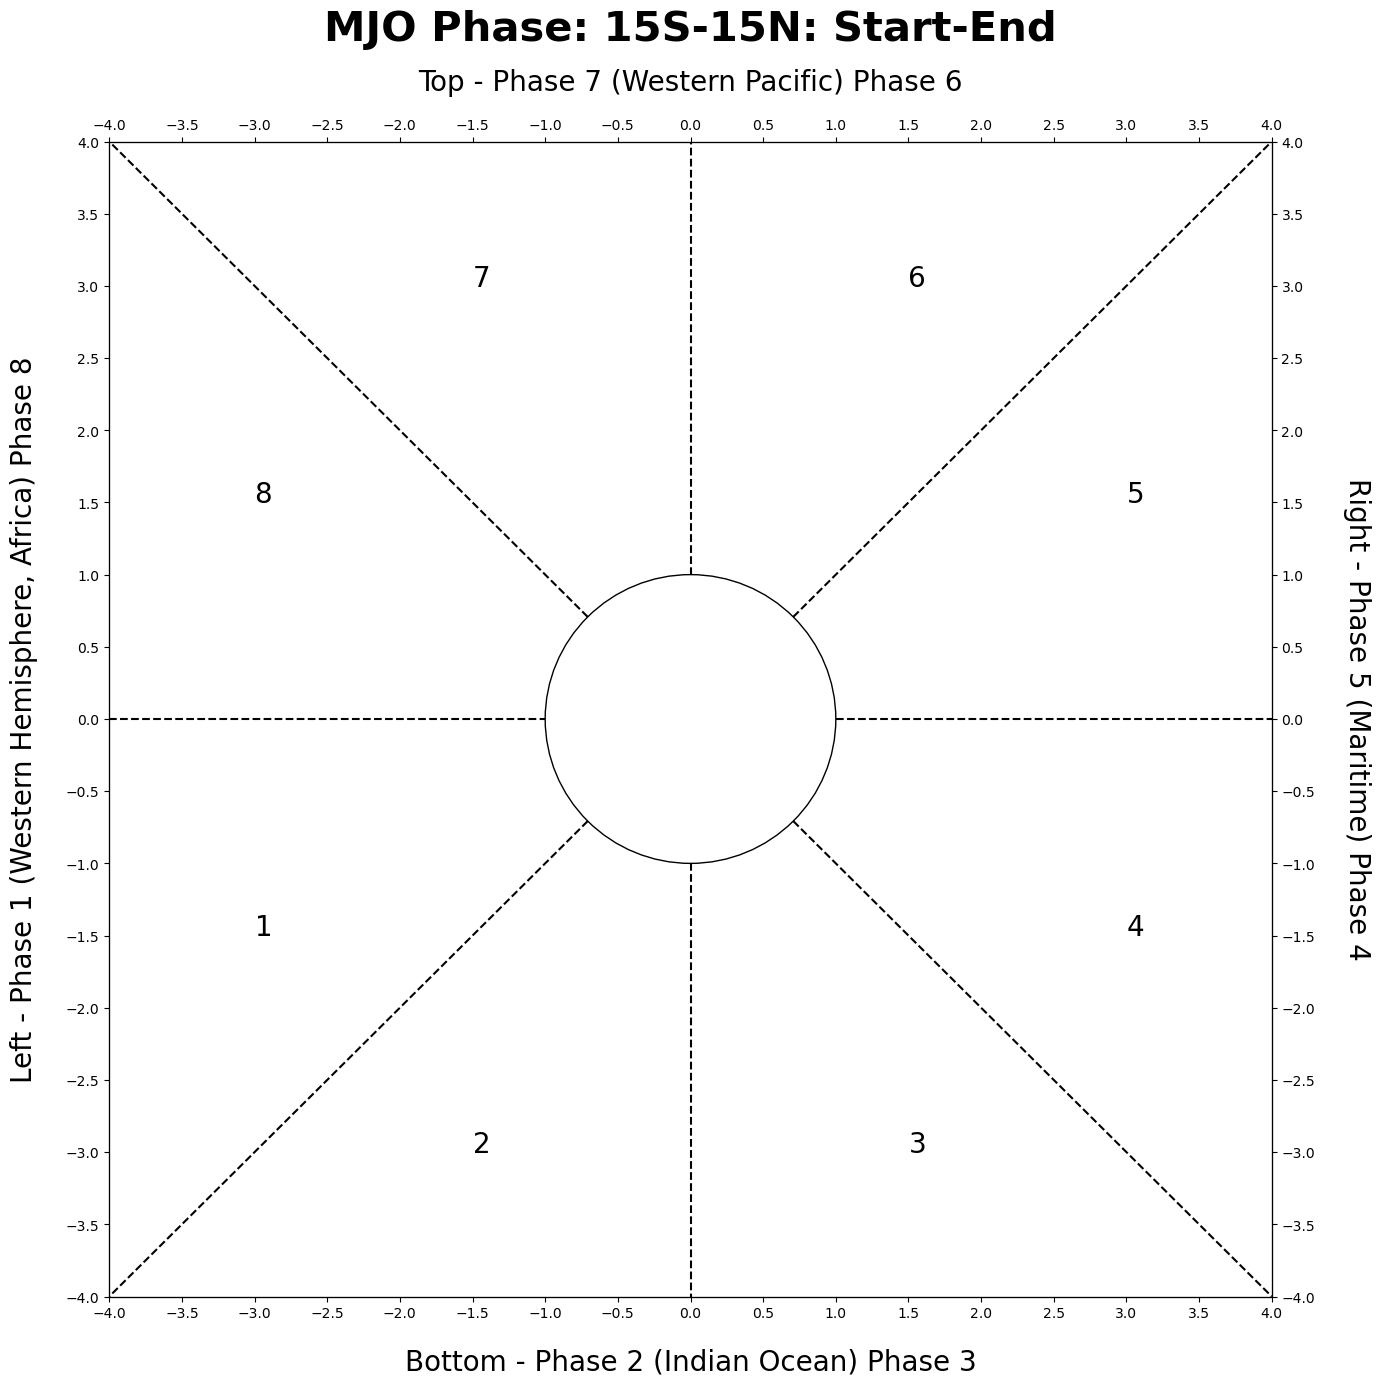

In [159]:
mjo_basemap(is_darkmode=False)

# MJO 4: Create MJO Lag Plots

Via `mjo_lag_lat_lon.ncl`

# MJO 5: Calculate MJO Spectra

Via `mjo_spectra.ncl`

# MJO 6: Calculate Principle Component from EOF Analysis

Via `mjo_EOF_cal.ncl`

# MJO 7: MJO Life Cycle Composite

Via `mjo_life_cycle_v2.ncl`